# 01 · Exploração inicial dos dados

### Índice

1. Setup
2. Leitura e tipagem
3. Visão geral da base
4. Valores ausentes
5. Distribuições
6. Diagnóstico de qualidade
7. A variável-alvo
8. Síntese do diagnóstico

Nenhum dado é alterado aqui. A base sai deste notebook exatamente como entrou.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# O notebook mora em notebooks/ e o dado em data/raw/, então o caminho relativo
# sobe um nível. O fallback cobre o caso de alguém rodar a partir da raiz do repo.
CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)      # 16 colunas cabem sem truncar
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"arquivo: {CSV.resolve()}")

pandas 3.0.6  ·  numpy 2.5.3
arquivo: /home/inteli/Documents/Klubi/Data-Analysis/data/raw/habitos_e_desempenho_estudantil.csv


In [2]:
# Paleta fixa do projeto. Cada cor tem um papel e não muda de gráfico para gráfico:
# azul é sempre "o dado", vermelho é sempre "olhe aqui, tem problema". Isso mantém
# a leitura consistente entre os notebooks da entrega.
COR = {
    "serie_1":    "#2a78d6",  # azul, série principal
    "serie_2":    "#eb6834",  # laranja, série de contraste
    "critico":    "#d03b3b",  # vermelho, reservado para sinalizar problema
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
}

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",   # título alinhado à esquerda acompanha a leitura
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,    # menos moldura, mais dado
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,     # grade atrás das barras, nunca por cima
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",      # grade sólida; tracejado lê como "projeção"
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax

## 2. Leitura e tipagem

In [3]:
# Leitura crua: dtype=str e na_filter=False desligam toda conversão automática do
# pandas. O que entra no DataFrame é byte a byte o que está no arquivo, sem nenhum
# palpite do parser sobre tipo ou sobre o que seria "ausente".
cru = pd.read_csv(CSV, dtype=str, na_filter=False)

print(f"{cru.shape[0]} linhas × {cru.shape[1]} colunas")
print(f"células vazias no arquivo: {int((cru == '').sum().sum())}")

1000 linhas × 16 colunas
células vazias no arquivo: 0


In [4]:
# O read_csv padrão converteria automaticamente uma lista de strings em NaN.
# Vale conferir quais são antes de deixar isso acontecer em silêncio.
from pandas._libs.parsers import STR_NA_VALUES

print("Strings que o read_csv trata como ausente por padrão:\n")
print(", ".join(repr(v) for v in sorted(STR_NA_VALUES)))

Strings que o read_csv trata como ausente por padrão:

'', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan', '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'None', 'n/a', 'nan', 'null'


In [5]:
# E o que a coluna de escolaridade dos pais realmente contém, sem conversão nenhuma.
(cru["parental_education_level"]
   .value_counts()
   .to_frame("linhas")
   .assign(pct=lambda d: 100 * d["linhas"] / len(cru)))

,linhas,pct
parental_education_level,,
High School,392,39.20
Bachelor,350,35.00
Master,167,16.70
None,91,9.10


`parental_education_level` guarda a string `"None"` em 91 das 1.000 linhas, e essa string está na lista de conversão automática do pandas mostrada acima. Sem cuidado, ela viraria `NaN` no meio da leitura, sem nenhum aviso.

In [6]:
# Conversão explícita. Só as colunas que são numéricas de fato mudam de tipo;
# as demais continuam texto, incluindo parental_education_level, que preserva
# o "None" como string em vez de virar NaN.
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = [
    "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exam_score",
]

df = cru.copy()
df[INTEIRAS] = df[INTEIRAS].astype(int)
df[DECIMAIS] = df[DECIMAIS].astype(float)

# Ordem usada em toda análise numérica daqui para frente.
numericas = ["exam_score"] + DECIMAIS[:-1] + INTEIRAS

print(f"colunas convertidas: {len(INTEIRAS + DECIMAIS)}")
print(f"NaN no DataFrame final: {int(df.isna().sum().sum())}")

colunas convertidas: 9
NaN no DataFrame final: 0


## 3. Visão geral da base

In [7]:
df.info(memory_usage="deep") # Serve para mostrar um resumo da estrutura do DataFrame,
# incluindo quanto de memória ele realmente está usando.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   str    
 12  internet_quality               1000 non-null   str    
 13  

In [8]:
df.head(8)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.00,1.20,1.10,No,85.00,8.00,Fair,6,Master,Average,8,Yes,56.20
1,S1001,20,Female,6.90,2.80,2.30,No,97.30,4.60,Good,6,High School,Average,8,No,100.00
2,S1002,21,Male,1.40,3.10,1.30,No,94.80,8.00,Poor,1,High School,Poor,1,No,34.30
3,S1003,23,Female,1.00,3.90,1.00,No,71.00,9.20,Poor,4,Master,Good,1,Yes,26.80
4,S1004,19,Female,5.00,4.40,0.50,No,90.90,4.90,Fair,3,Master,Good,1,No,66.40
5,S1005,24,Male,7.20,1.30,0.00,No,82.90,7.40,Fair,1,Master,Average,4,No,100.00
6,S1006,21,Female,5.60,1.50,1.40,Yes,85.80,6.50,Good,2,Master,Poor,4,No,89.80
7,S1007,21,Female,4.30,1.00,2.00,Yes,77.70,4.60,Fair,0,Bachelor,Average,8,No,72.60


### Dicionário de dados

O desafio não veio com dicionário, então este é o entendimento que a própria base sustenta.

| Coluna | Descrição | Tipo | Domínio observado |
|---|---|---|---|
| `student_id` | Identificador do aluno | texto | `S1000` a `S1999`, único |
| `age` | Idade | inteiro | 17 a 24 |
| `gender` | Gênero | categórico | Female, Male, Other |
| `study_hours_per_day` | Horas de estudo por dia | decimal | 0,0 a 8,3 |
| `social_media_hours` | Horas em redes sociais por dia | decimal | 0,0 a 7,2 |
| `netflix_hours` | Horas de streaming por dia | decimal | 0,0 a 5,4 |
| `part_time_job` | Trabalha meio período | binário | Yes, No |
| `attendance_percentage` | Frequência às aulas | percentual | 56,0 a 100,0 |
| `sleep_hours` | Horas de sono por noite | decimal | 3,2 a 10,0 |
| `diet_quality` | Qualidade da alimentação | ordinal | Poor < Fair < Good |
| `exercise_frequency` | Vezes que se exercita por semana | inteiro | 0 a 6 |
| `parental_education_level` | Escolaridade dos pais | ordinal | None < High School < Bachelor < Master |
| `internet_quality` | Qualidade da internet | ordinal | Poor < Average < Good |
| `mental_health_rating` | Autoavaliação de saúde mental | ordinal | 1 a 10 |
| `extracurricular_participation` | Participa de atividade extracurricular | binário | Yes, No |
| `exam_score` | Nota da prova, **variável-alvo** | decimal | 18,4 a 100,0 |

Três observações que já mudam como as colunas devem ser tratadas:

1. **Quatro colunas são ordinais disfarçadas.** `diet_quality`, `internet_quality` e `parental_education_level` chegam como texto sem ordem; `mental_health_rating` chega como inteiro, mas é uma escala subjetiva de 1 a 10, não uma contagem. A distância entre "Poor" e "Fair" não é necessariamente a mesma entre "Fair" e "Good", e saúde mental 8 não é o dobro de 4. `exercise_frequency` também vai de 0 a 6, mas é dias por semana: uma contagem de verdade, sem essa ressalva.
2. **`student_id` é identificador, não variável.** Nunca deve entrar em correlação ou modelo, porque é sequencial e correlacionaria com qualquer coisa que tenha ordem no arquivo.
3. **`exam_score` é o alvo.** Toda a análise seguinte gira em torno de explicá-la.

## 4. Valores ausentes: os 91 `"None"`

A seção 2 mostrou que o `"None"` é ambíguo. Ele pode ser:

1. **"Os pais não têm educação formal"**, uma categoria legítima, e provavelmente a mais interessante da coluna: o grupo de menor renda e menor apoio em casa. Descartá-la apagaria justamente quem mais deveria aparecer numa análise sobre desempenho escolar.
2. **"Não respondeu"**, ausência de verdade, e tratá-la como categoria inventaria um grupo que não existe.

Os dois caminhos são defensáveis, e escolher errado enviesa tudo que vier depois. A pergunta que a base consegue responder é outra: **esses 91 alunos são diferentes dos outros 909?**

Se `"None"` fosse só gente que pulou a pergunta, o grupo seria um recorte aleatório: mesma nota média, mesmos hábitos. Se tiver perfil próprio, o "faltar" carrega informação.

In [9]:
# Máscara sobre o texto original. Como a leitura foi crua, o "None" ainda está lá
# como string e dá para separar os grupos sem ter perdido nada.
grupo = np.where(df["parental_education_level"].eq("None"), "'None' (91)", "Informado (909)")

perfil = df[numericas].groupby(grupo).mean().T
perfil.columns.name = None
perfil["diferenca"] = perfil["'None' (91)"] - perfil["Informado (909)"]

# A diferença bruta não é comparável entre colunas (horas, pontos, percentual),
# então divido pelo desvio-padrão de cada uma para pôr tudo na mesma régua.
perfil["dif_em_desvios"] = perfil["diferenca"] / df[numericas].std()
perfil

,'None' (91),Informado (909),diferenca,dif_em_desvios
exam_score,70.03,69.56,0.48,0.03
study_hours_per_day,3.66,3.54,0.13,0.09
social_media_hours,2.51,2.50,0.01,0.01
netflix_hours,1.71,1.83,-0.12,-0.11
attendance_percentage,86.64,83.88,2.76,0.29
sleep_hours,6.43,6.47,-0.04,-0.04
age,20.73,20.48,0.25,0.11
exercise_frequency,2.95,3.05,-0.11,-0.05
mental_health_rating,5.15,5.47,-0.31,-0.11


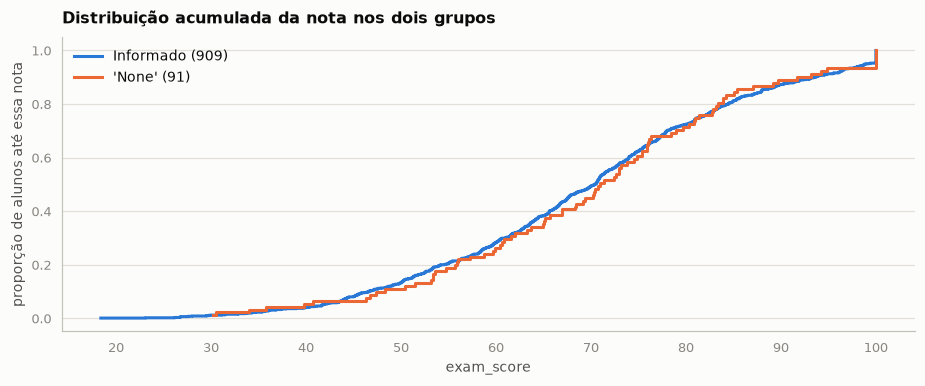

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))

# Acumulada (ECDF) em vez de histograma: com 91 observações de um lado e 909 do
# outro, a forma do histograma diria mais sobre a largura de bin escolhida do que
# sobre os dados. A acumulada não precisa de bin nenhum.
for rotulo, cor in [("Informado (909)", COR["serie_1"]), ("'None' (91)", COR["serie_2"])]:
    x = np.sort(df.loc[grupo == rotulo, "exam_score"].to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", linewidth=2, color=cor, label=rotulo)

ax.set_title("Distribuição acumulada da nota nos dois grupos")
ax.set_xlabel("exam_score")
ax.set_ylabel("proporção de alunos até essa nota")
ax.legend(loc="upper left")
so_grade(ax)
plt.tight_layout()
plt.show()

**As maiores diferenças ficam abaixo de 0,2 desvio-padrão**, inclusive na nota, que é o que realmente importa. E as duas curvas acumuladas ficam praticamente coladas em toda a faixa: em qualquer nota que se escolha, a proporção de alunos abaixo dela é a mesma nos dois grupos. Não há sinal de que esses 91 sejam um grupo distinto.

Isso é evidência útil, mas não fecha a questão. Se `"None"` fosse mesmo "pais sem educação formal", eu esperaria alguma diferença de desempenho, já que escolaridade dos pais é um dos preditores mais estáveis da literatura educacional. Não ver nada é mais compatível com ausência aleatória, alguém que pulou a pergunta. Ainda assim é circunstancial, não prova.

O que dá para afirmar com segurança:

1. São 9,1% da base, grande demais para descartar as linhas e pequeno demais para condenar a coluna.
2. Qualquer que seja a escolha, ela muda pouco o resultado, porque os grupos são estatisticamente indistinguíveis.
3. A escolha precisa ser explícita e registrada, porque um `read_csv` sem parâmetro já a toma sozinho.

A decisão de tratamento fica para o notebook 02, com essa evidência na mão.

## 5. Distribuições

### 5.1 Variáveis numéricas

In [11]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
exam_score,"1,000.00",69.60,16.89,18.40,58.48,70.50,81.33,100.00
study_hours_per_day,"1,000.00",3.55,1.47,0.00,2.60,3.50,4.50,8.30
social_media_hours,"1,000.00",2.51,1.17,0.00,1.70,2.50,3.30,7.20
netflix_hours,"1,000.00",1.82,1.08,0.00,1.00,1.80,2.52,5.40
attendance_percentage,"1,000.00",84.13,9.40,56.00,78.00,84.40,91.03,100.00
sleep_hours,"1,000.00",6.47,1.23,3.20,5.60,6.50,7.30,10.00
age,"1,000.00",20.50,2.31,17.00,18.75,20.00,23.00,24.00
exercise_frequency,"1,000.00",3.04,2.03,0.00,1.00,3.00,5.00,6.00
mental_health_rating,"1,000.00",5.44,2.85,1.00,3.00,5.00,8.00,10.00


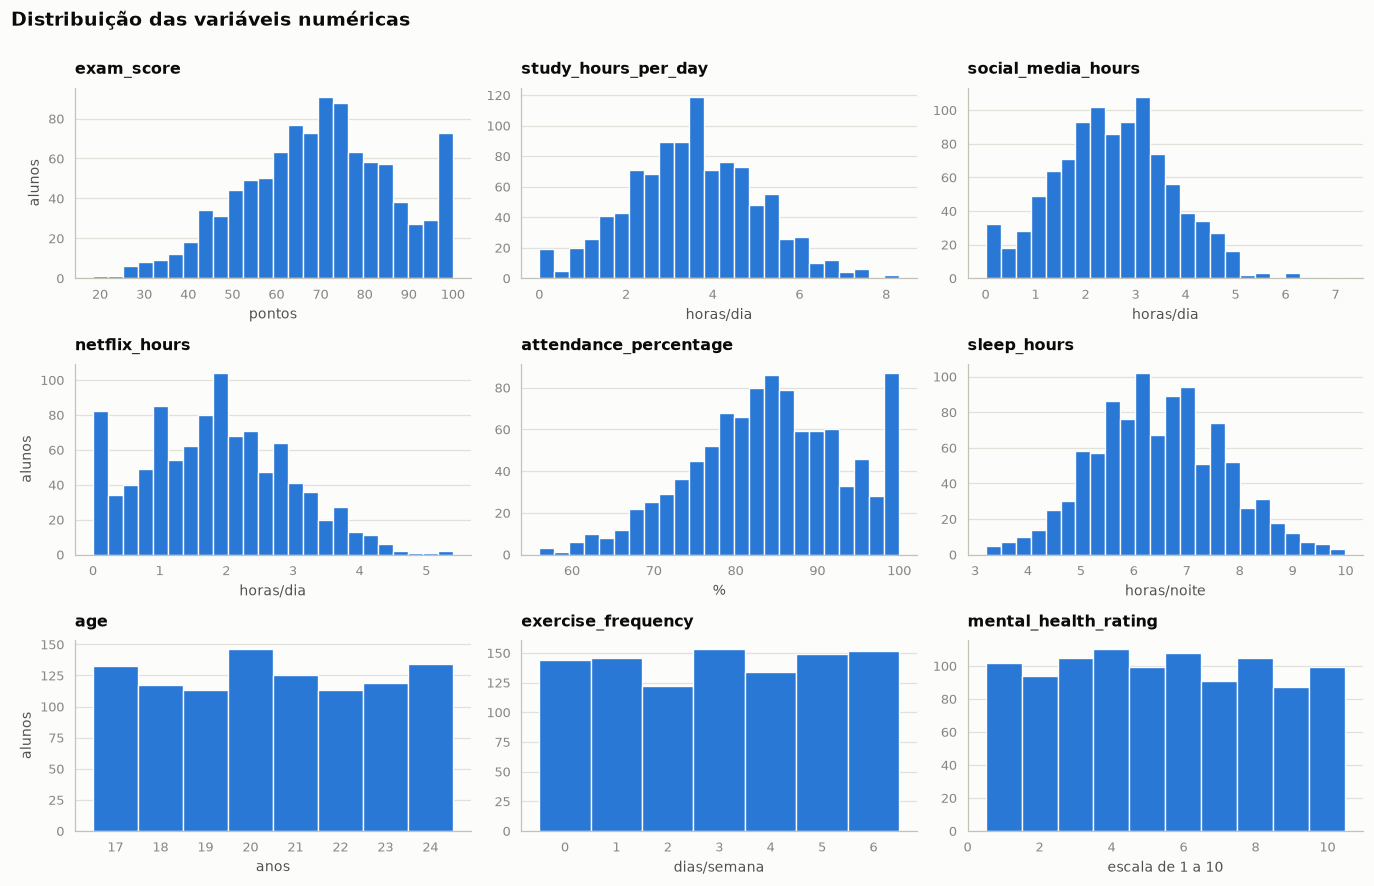

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(12.5, 8))

# Unidade de cada variável, para o eixo x. O título já diz o nome da coluna;
# isso diz em que ela é medida.
UNIDADE = {
    "exam_score": "pontos", "study_hours_per_day": "horas/dia",
    "social_media_hours": "horas/dia", "netflix_hours": "horas/dia",
    "attendance_percentage": "%", "sleep_hours": "horas/noite",
    "age": "anos", "exercise_frequency": "dias/semana",
    "mental_health_rating": "escala de 1 a 10",
}

# Variáveis que só assumem valores inteiros ganham um bin por valor. Com um número
# fixo de bins apareceriam buracos artificiais entre os inteiros, e a distribuição
# pareceria mais esparsa do que é.
for i, (ax, coluna) in enumerate(zip(axes.flat, numericas)):
    if coluna in INTEIRAS:
        faixa = np.arange(df[coluna].min() - 0.5, df[coluna].max() + 1.5)
    else:
        faixa = 24

    ax.hist(
        df[coluna], bins=faixa, color=COR["serie_1"],
        # a borda em cor de fundo é o vão que separa as barras, não um contorno
        edgecolor=COR["superficie"], linewidth=0.9,
    )
    ax.set_title(coluna)
    ax.set_xlabel(UNIDADE[coluna])
    if i % 3 == 0:   # "alunos" só na coluna da esquerda, não precisa repetir 9 vezes
        ax.set_ylabel("alunos")
    so_grade(ax)

# Sobra um eixo vazio na grade 3x3 com 9 variáveis? Remove o que não for usado.
for ax in axes.flat[len(numericas):]:
    ax.remove()

fig.suptitle(
    "Distribuição das variáveis numéricas",
    x=0.005, ha="left", fontsize=12.5, fontweight="bold", y=1.0,
)
plt.tight_layout()
plt.show()

Três formatos aparecem aí, e cada um diz uma coisa:

1. **Sino bem-comportado** em `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `sleep_hours`, `attendance_percentage` e `exam_score`. Simétricas, sem cauda suja, sem valor absurdo.
2. **Praticamente uniforme** em `age`, `exercise_frequency` e `mental_health_rating`. Todos os valores aparecem com frequência parecida, o que é incomum em dado real: idade de estudante costuma concentrar numa faixa, e autoavaliação de saúde mental costuma puxar para o meio da escala.
3. **Encostada no limite** em `exam_score` e `attendance_percentage`, que empilham massa exatamente no teto. É o achado da seção 6.4.

A uniformidade e a suavidade das curvas, juntas, apontam para base sintética ou fortemente tratada. Isso não invalida nada, mas calibra a expectativa: aqui não vão aparecer os problemas típicos de dado de produção, como erro de digitação, unidade trocada ou encoding quebrado. Os problemas desta base são de outra natureza, e mais sutis.

### 5.2 Variáveis categóricas

In [13]:
categoricas = [
    "gender", "part_time_job", "diet_quality",
    "parental_education_level", "internet_quality", "extracurricular_participation",
]

# Ordinais recebem a ordem natural, não a de frequência: ordenar "Poor, Good, Fair"
# por contagem destruiria a informação de que a escala é crescente.
ORDENS = {
    "gender":                        ["Female", "Male", "Other"],
    "part_time_job":                 ["No", "Yes"],
    "diet_quality":                  ["Poor", "Fair", "Good"],
    "parental_education_level":      ["None", "High School", "Bachelor", "Master"],
    "internet_quality":              ["Poor", "Average", "Good"],
    "extracurricular_participation": ["No", "Yes"],
}

resumo = []
for coluna in categoricas:
    vc = df[coluna].value_counts().reindex(ORDENS[coluna])
    for categoria, n in vc.items():
        resumo.append({
            "coluna": coluna, "categoria": categoria,
            "linhas": int(n), "pct": round(100 * n / len(df), 1),
        })

pd.DataFrame(resumo).set_index(["coluna", "categoria"])

linhas   pct
coluna                        categoria                
gender                        Female          481 48.10
                              Male            477 47.70
                              Other            42  4.20
part_time_job                 No              785 78.50
                              Yes             215 21.50
diet_quality                  Poor            185 18.50
                              Fair            437 43.70
                              Good            378 37.80
parental_education_level      None             91  9.10
                              High School     392 39.20
                              Bachelor        350 35.00
                              Master          167 16.70
internet_quality              Poor            162 16.20
                              Average         391 39.10
                              Good            447 44.70
extracurricular_participation No              682 68.20
                              Yes             318 31.80

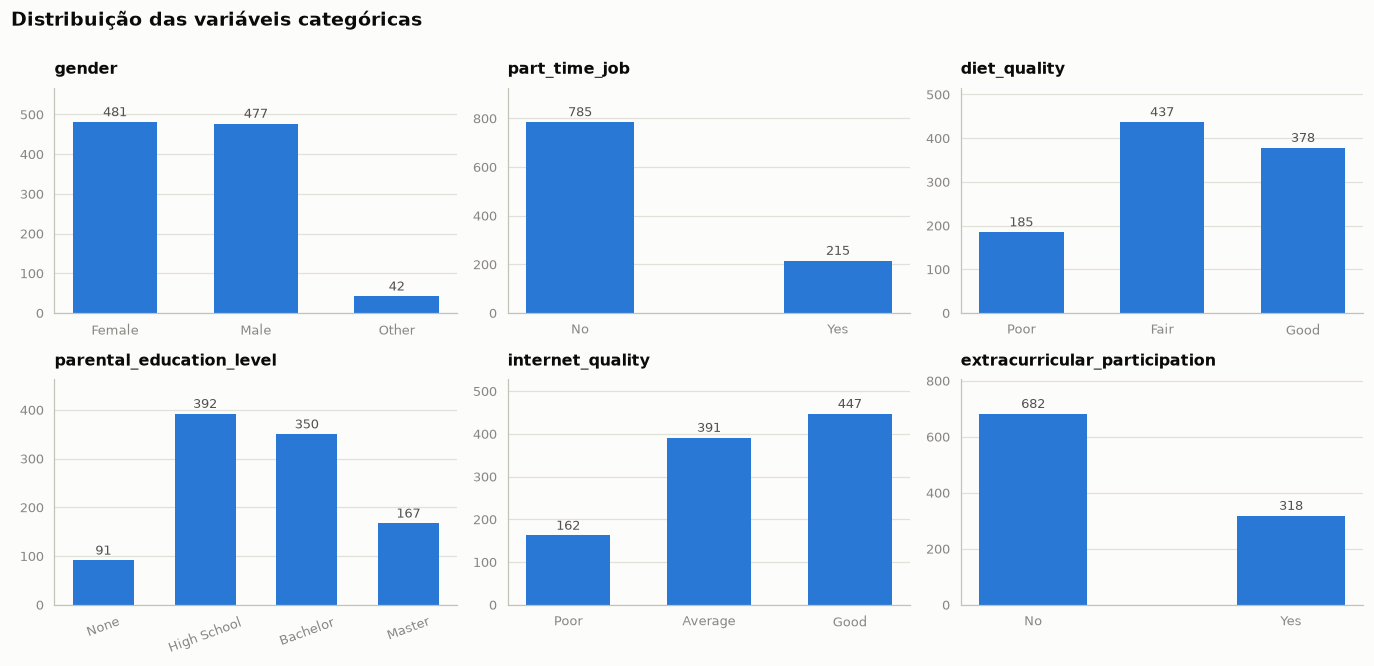

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))

for ax, coluna in zip(axes.flat, categoricas):
    vc = df[coluna].value_counts().reindex(ORDENS[coluna])

    ax.bar(
        vc.index, vc.values, color=COR["serie_1"],
        # a folga ao lado da barra é o respiro, não decoração; com 2 categorias a
        # barra precisa ser mais estreita para não virar um bloco
        width=0.42 if len(vc) <= 2 else 0.60,
    )

    # Rótulo direto no topo dispensa o leitor de mirar na grade para ler o valor.
    folga = max(vc.values) * 0.03
    ax.set_ylim(0, max(vc.values) * 1.18)
    for x, v in enumerate(vc.values):
        ax.text(x, v + folga, f"{v}", ha="center", fontsize=8.5, color=COR["tinta_2"])

    ax.set_title(coluna)
    ax.tick_params(axis="x", labelrotation=20 if coluna == "parental_education_level" else 0)
    so_grade(ax)

fig.suptitle(
    "Distribuição das variáveis categóricas",
    x=0.005, ha="left", fontsize=12.5, fontweight="bold", y=1.0,
)
plt.tight_layout()
plt.show()

Nenhuma categoria é rara a ponto de quebrar uma análise, mas duas merecem nota:

1. **`gender == "Other"` tem 42 alunos (4,2%).** Pequeno demais para conclusão estatística confiável. Qualquer recorte por gênero precisa reportar o tamanho do grupo junto do resultado: uma diferença de 3 pontos na média de 42 pessoas não significa a mesma coisa que numa de 481.
2. **`part_time_job` e `extracurricular_participation` são desbalanceadas** (78,5% e 68,2% no "No"). Nada anormal, mas o grupo minoritário tem menos poder estatístico, e costuma ser ele a hipótese interessante.

As categorias em si estão limpas: sem variação de maiúsculas, sem espaço sobrando, sem sinônimo duplicado. A seção 6.3 confirma isso com código em vez de com olho.

## 6. Diagnóstico de qualidade

Seis verificações, cada uma com o código que a testa e o veredito. Nada de "parece ok".

### 6.1 Unicidade e duplicatas

In [15]:
# Três testes, do mais óbvio ao mais revelador. O último é o que vale: duas linhas
# com ids diferentes mas todo o resto igual seriam sinal clássico de duplicação na
# coleta, e passariam batido pelos dois primeiros.
sem_id = df.drop(columns="student_id")

print(f"linhas                                : {len(df)}")
print(f"student_id únicos                     : {df['student_id'].nunique()}")
print(f"linhas idênticas (todas as colunas)   : {df.duplicated().sum()}")
print(f"linhas idênticas ignorando student_id : {sem_id.duplicated().sum()}")

linhas                                : 1000
student_id únicos                     : 1000
linhas idênticas (todas as colunas)   : 0
linhas idênticas ignorando student_id : 0


**Passa.** Cada linha é um aluno distinto, e não há sinal de duplicação na coleta.

### 6.2 Domínios válidos

In [16]:
# Intervalo plausível de cada variável, declarado antes de olhar o dado. Declarar
# primeiro evita o viés de aceitar como normal justamente o que está errado.
DOMINIOS = {
    "age":                   (17, 24),
    "study_hours_per_day":   (0, 24),
    "social_media_hours":    (0, 24),
    "netflix_hours":         (0, 24),
    "attendance_percentage": (0, 100),
    "sleep_hours":           (0, 24),
    "exercise_frequency":    (0, 7),
    "mental_health_rating":  (1, 10),
    "exam_score":            (0, 100),
}

checagem = []
for coluna, (minimo, maximo) in DOMINIOS.items():
    fora = ((df[coluna] < minimo) | (df[coluna] > maximo)).sum()
    checagem.append({
        "coluna": coluna,
        "esperado": f"[{minimo}, {maximo}]",
        "observado": f"[{df[coluna].min():g}, {df[coluna].max():g}]",
        "fora_do_dominio": int(fora),
        "veredito": "ok" if fora == 0 else "FALHA",
    })

pd.DataFrame(checagem).set_index("coluna")

,esperado,observado,fora_do_dominio,veredito
coluna,,,,
age,"[17, 24]","[17, 24]",0,ok
study_hours_per_day,"[0, 24]","[0, 8.3]",0,ok
social_media_hours,"[0, 24]","[0, 7.2]",0,ok
netflix_hours,"[0, 24]","[0, 5.4]",0,ok
attendance_percentage,"[0, 100]","[56, 100]",0,ok
sleep_hours,"[0, 24]","[3.2, 10]",0,ok
exercise_frequency,"[0, 7]","[0, 6]",0,ok
mental_health_rating,"[1, 10]","[1, 10]",0,ok
exam_score,"[0, 100]","[18.4, 100]",0,ok


**Passa.** Nenhum valor fora do intervalo plausível: sem idade negativa, sem nota acima de 100, sem 30 horas de sono.

### 6.3 Consistência dos rótulos categóricos

In [17]:
problemas = []
for coluna in categoricas + ["student_id"]:
    valores = df[coluna].unique()

    # Espaço sobrando é invisível na tela mas cria categoria nova no groupby.
    com_espaco = [v for v in valores if v != v.strip()]

    # Rótulos que só diferem por caixa ou espaço são o mesmo rótulo digitado de
    # dois jeitos. Normalizo e procuro duplicata no resultado.
    normalizados = pd.Series([v.strip().lower() for v in valores])
    colisoes = normalizados[normalizados.duplicated()].tolist()

    if com_espaco or colisoes:
        problemas.append({"coluna": coluna, "espaco_sobrando": com_espaco, "colisoes": colisoes})

print(f"colunas com rótulo inconsistente: {len(problemas)}")
print(problemas if problemas else "nenhuma, os rótulos estão padronizados")

colunas com rótulo inconsistente: 0
nenhuma, os rótulos estão padronizados


**Passa.** Nada de `"Good"` convivendo com `"good"` ou `"Good "`. Em base coletada por formulário isso é raro, mais uma pista de que a base é sintética.

### 6.4 Efeito teto, o achado mais importante desta seção

In [18]:
# Quantas linhas estão exatamente no valor máximo de cada coluna. Um empilhamento
# grande no máximo é assinatura de medida cortada, não de cauda natural.
teto = pd.DataFrame([
    {
        "coluna": coluna,
        "máximo": df[coluna].max(),
        "linhas_no_máximo": int((df[coluna] == df[coluna].max()).sum()),
        "pct_no_máximo": round(100 * (df[coluna] == df[coluna].max()).mean(), 1),
    }
    for coluna in ["exam_score", "attendance_percentage", "study_hours_per_day", "sleep_hours"]
]).set_index("coluna")
teto

,máximo,linhas_no_máximo,pct_no_máximo
coluna,,,
exam_score,100.00,48,4.80
attendance_percentage,100.00,66,6.60
study_hours_per_day,8.30,1,0.10
sleep_hours,10.00,2,0.20


último bin [98, 100]: 63 alunos, dos quais 48 estão exatamente em 100,0


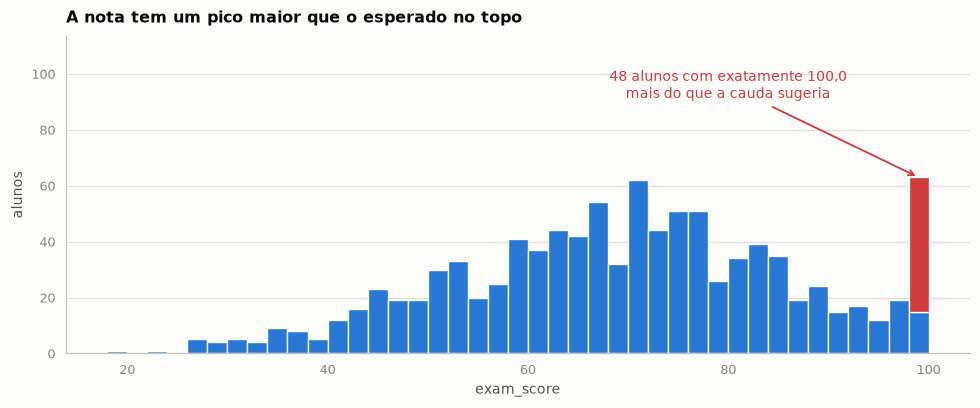

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.8))

n_teto = int((df["exam_score"] == 100).sum())

# O histograma cobre só quem ficou abaixo de 100. Quem está exatamente em 100 entra
# como segmento vermelho empilhado sobre o último bin, para que a altura vermelha
# seja literalmente o número anotado, e não o bin [98, 100] inteiro.
alturas, _, _ = ax.hist(
    df.loc[df["exam_score"] < 100, "exam_score"],
    bins=np.arange(18, 101, 2), color=COR["serie_1"],
    edgecolor=COR["superficie"], linewidth=0.9,
)
ax.bar(
    99, n_teto, bottom=alturas[-1], width=2,
    color=COR["critico"], edgecolor=COR["superficie"], linewidth=0.9,
)

topo = alturas[-1] + n_teto
ax.annotate(
    f"{n_teto} alunos com exatamente 100,0"
    "\nmais do que a cauda sugeria",
    xy=(99, topo), xytext=(80, topo * 1.45),
    color=COR["critico"], fontsize=9, ha="center",
    arrowprops=dict(arrowstyle="->", color=COR["critico"], linewidth=1.2),
)

print(f"último bin [98, 100]: {int(topo)} alunos, "
      f"dos quais {n_teto} estão exatamente em 100,0")

ax.set_title("A nota tem um pico maior que o esperado no topo")
ax.set_xlabel("exam_score")
ax.set_ylabel("alunos")
ax.set_ylim(0, max(alturas.max(), topo) * 1.8)
so_grade(ax)
plt.tight_layout()
plt.show()

**Ressalva séria.** 48 alunos (4,8%) têm nota exatamente 100,0, o máximo possível numa prova de 0 a 100. O histograma mostra por que isso merece atenção: em vez da cauda que a distribuição vinha desenhando, há um pico bem maior que o esperado no último ponto.

Não existe nota acima de 100, pela mesma razão que não existe frequência acima de 100% em `attendance_percentage`, que tem esse mesmo pico (66 alunos em 100,0%): é o teto genuíno da escala, não um limite do instrumento escondendo um valor mais alto. O que faz o pico merecer atenção, mesmo sendo um teto legítimo, é a distorção estatística que ele carrega:

1. **Um modelo linear ajustado à base inteira sai com inclinação mais suave que a que opera longe do teto.** Perto de 100 a nota não tem como continuar subindo, e esses alunos puxam a reta inteira para uma inclinação mais achatada do que a que vale para quem está longe do teto. O conserto certo seria uma curva que satura perto de 100 em vez de uma reta, e não é o que este projeto usa: o caminho aqui foi aceitar o viés sabendo dele.
2. **A correlação de Pearson com a nota vem levemente atenuada**, pela mesma compressão.
3. **Média de nota comparada entre grupos fica enganosa** quando os grupos têm proporções diferentes de alunos no teto: a média do grupo forte é puxada para baixo mais do que a do grupo fraco.

### 6.5 Coerência do orçamento de tempo

In [20]:
# Teste de coerência interna: as horas declaradas nas quatro atividades precisam
# caber num dia. Base real falha esse teste com frequência.
horas = ["study_hours_per_day", "social_media_hours", "netflix_hours", "sleep_hours"]
declaradas = df[horas].sum(axis=1)

print("horas/dia declaradas (estudo + redes + streaming + sono)")
print(f"  mínimo  : {declaradas.min():.1f} h")
print(f"  mediana : {declaradas.median():.1f} h")
print(f"  máximo  : {declaradas.max():.1f} h")
print()
print(f"  linhas acima de 24 h (impossível) : {(declaradas > 24).sum()}")
print(f"  linhas acima de 18 h (apertado)   : {(declaradas > 18).sum()}")

horas/dia declaradas (estudo + redes + streaming + sono)
  mínimo  : 6.8 h
  mediana : 14.3 h
  máximo  : 21.5 h

  linhas acima de 24 h (impossível) : 0
  linhas acima de 18 h (apertado)   : 77


**Passa, com ressalva.** Nenhuma linha estoura as 24 horas do dia.

Mas 77 alunos (7,7%) declaram mais de 18 horas nessas quatro atividades, o que deixa menos de 6 horas para assistir aula, se deslocar, comer e todo o resto. Não é impossível, e a base não permite provar que está errado. Fica registrado como limite de plausibilidade: se alguma conclusão do projeto depender exatamente desses alunos, vale reexaminá-los.

### 6.6 Outliers (IQR)

In [21]:
def contar_outliers(serie):
    "Cercas de Tukey: 1,5 IQR além do primeiro e do terceiro quartil."
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return {
        "limite_inf": limite_inf,
        "limite_sup": limite_sup,
        "abaixo": int((serie < limite_inf).sum()),
        "acima": int((serie > limite_sup).sum()),
    }

pd.DataFrame({c: contar_outliers(df[c]) for c in numericas}).T

,limite_inf,limite_sup,abaixo,acima
exam_score,24.20,115.60,2.00,0.00
study_hours_per_day,-0.25,7.35,0.00,7.00
social_media_hours,-0.70,5.70,0.00,5.00
netflix_hours,-1.29,4.81,0.00,4.00
attendance_percentage,58.46,110.56,3.00,0.00
sleep_hours,3.05,9.85,0.00,2.00
age,12.38,29.38,0.00,0.00
exercise_frequency,-5.00,11.00,0.00,0.00
mental_health_rating,-4.50,15.50,0.00,0.00


**Passa.** Praticamente nenhum ponto fora das cercas, e os poucos que aparecem são valores plausíveis nas pontas, não erro de medida.

Vale separar o que isso significa do que não significa: a regra do IQR aponta pontos distantes da massa, não pontos errados. Numa base como esta, sem outlier algum, ela confirma que não há lixo evidente. **Nenhuma linha será removida**, porque remover ponta legítima é fabricar um resultado mais bonito do que os dados sustentam.

## 7. A variável-alvo: `exam_score`

Fecho olhando a variável que todo o resto do projeto vai tentar explicar. Sem correlações ainda, que são assunto do notebook 03.

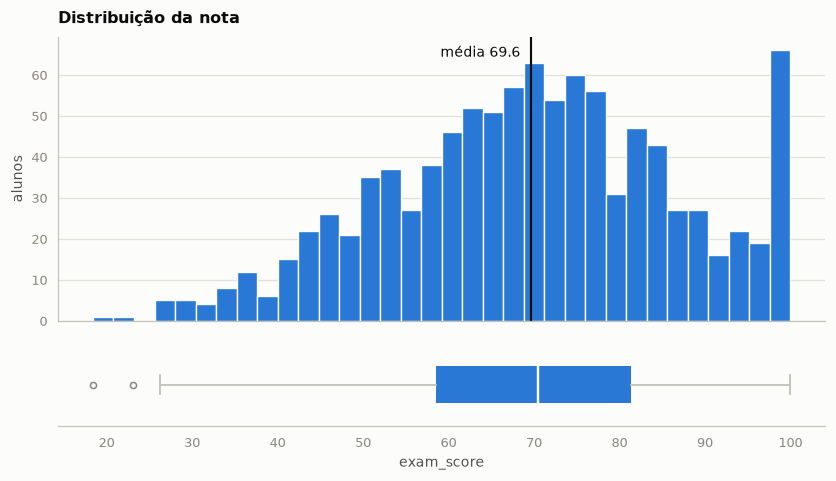

In [22]:
# Histograma e boxplot compartilhando o eixo x: o de cima mostra a forma, o de
# baixo resume quartis e pontas no mesmo referencial, sem o leitor trocar de escala.
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, figsize=(9, 4.6), sharex=True,
    gridspec_kw={"height_ratios": [3.4, 1], "hspace": 0.12},
)

ax_hist.hist(
    df["exam_score"], bins=34, color=COR["serie_1"],
    edgecolor=COR["superficie"], linewidth=0.9,
)
ax_hist.axvline(df["exam_score"].mean(), color=COR["tinta"], linewidth=1.4)
ax_hist.text(
    df["exam_score"].mean() - 1.2, ax_hist.get_ylim()[1] * 0.93,
    f"média {df['exam_score'].mean():.1f}", ha="right", fontsize=9, color=COR["tinta"],
)
ax_hist.set_title("Distribuição da nota")
ax_hist.set_ylabel("alunos")
so_grade(ax_hist)

ax_box.boxplot(
    df["exam_score"], orientation="horizontal", widths=0.45, patch_artist=True,
    # mediana em cor de fundo: o vão branco sobre o azul marca a posição sem
    # acrescentar mais uma cor ao gráfico
    medianprops=dict(color=COR["superficie"], linewidth=1.6),
    boxprops=dict(facecolor=COR["serie_1"], edgecolor="none"),
    whiskerprops=dict(color=COR["eixo"], linewidth=1.2),
    capprops=dict(color=COR["eixo"], linewidth=1.2),
    flierprops=dict(markeredgecolor=COR["suave"], markersize=4),
)
ax_box.set_yticks([])
ax_box.set_xlabel("exam_score")
ax_box.grid(visible=False)
ax_box.spines["left"].set_visible(False)

plt.show()

In [23]:
nota = df["exam_score"]
print(f"média            : {nota.mean():.1f}")
print(f"mediana          : {nota.median():.1f}")
print(f"desvio-padrão    : {nota.std():.1f}")
print(f"mínimo / máximo  : {nota.min():.1f} / {nota.max():.1f}")
print(f"assimetria       : {nota.skew():+.2f}")
print(f"abaixo de 60     : {(nota < 60).sum()} alunos ({100 * (nota < 60).mean():.1f}%)")
print(f"exatamente 100   : {(nota == 100).sum()} alunos ({100 * (nota == 100).mean():.1f}%)")

média            : 69.6
mediana          : 70.5
desvio-padrão    : 16.9
mínimo / máximo  : 18.4 / 100.0
assimetria       : -0.16
abaixo de 60     : 280 alunos (28.0%)
exatamente 100   : 48 alunos (4.8%)


Distribuição larga e quase simétrica, centrada em 69,6 com desvio-padrão de 16,9. **Há variação de sobra para explicar**, que é o que o resto do projeto precisa: uma base onde todo mundo tira nota parecida não sustentaria nenhuma das tarefas seguintes.

A assimetria levemente negativa e o pico em 100 são a mesma coisa vista de dois ângulos: o teto empurra massa da cauda direita para dentro, como a seção 6 discute.

## 8. Síntese do diagnóstico

**1.000 alunos × 16 colunas. Nenhuma célula vazia, nenhuma duplicata, nenhum valor fora de domínio, nenhum outlier relevante.** Pelos critérios usuais a base está limpa, e nada aqui precisa ser jogado fora.

### Próximo passo

**Notebook 02, engenharia de dados**: codificar as ordinais preservando a ordem e criar as variáveis derivadas (faixas de uso de redes sociais, de sono e de estudo).